<a href="https://colab.research.google.com/github/elenadaniels85-glitch/CUNY-Data-Analytics/blob/main/NYPDarrests_Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("https://data.cityofnewyork.us/resource/uip8-fykc.csv?$limit=280000")

In [3]:
df.shape

(278953, 19)

In [4]:
df.head()

,arrest_key,arrest_date,pd_cd,pd_desc,ky_cd,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race,x_coord_cd,y_coord_cd,latitude,longitude,geocoded_column
0,299201470,2025-01-10T00:00:00.000,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,2025-01-13T00:00:00.000,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,2025-01-13T00:00:00.000,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,2025-02-12T00:00:00.000,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,2025-02-12T00:00:00.000,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [5]:
df.tail()

,arrest_key,arrest_date,pd_cd,pd_desc,ky_cd,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race,x_coord_cd,y_coord_cd,latitude,longitude,geocoded_column
278948,318159497,2025-12-30T00:00:00.000,339,"LARCENY,PETIT FROM OPEN AREAS,",341.0,PETIT LARCENY,PL 1552500,M,K,70,0,(null),(null),BLACK,999359,169275,40.631293,-73.945566,POINT (-73.945566 40.631293)
278949,318206208,2025-12-31T00:00:00.000,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,M,25,0,25-44,F,BLACK,1000581,231070,40.800904,-73.941012,POINT (-73.941012 40.800904)
278950,318144122,2025-12-30T00:00:00.000,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,110,0,18-24,F,BLACK,1024817,213376,40.752260,-73.853581,POINT (-73.853581 40.75226)
278951,318209021,2025-12-31T00:00:00.000,779,"PUBLIC ADMINISTRATION,UNCLASSI",126.0,MISCELLANEOUS PENAL LAW,PL 215510B,F,Q,109,0,25-44,M,BLACK HISPANIC,1040185,217007,40.762143,-73.798083,POINT (-73.798083 40.762143)
278952,318207879,2025-12-31T00:00:00.000,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL0511001,M,S,120,0,(null),(null),WHITE HISPANIC,964114,166065,40.622464,-74.072535,POINT (-74.07253516 40.62246362)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   arrest_key         278953 non-null  int64  
 1   arrest_date        278953 non-null  object 
 2   pd_cd              278953 non-null  int64  
 3   pd_desc            278953 non-null  object 
 4   ky_cd              278930 non-null  float64
 5   ofns_desc          278953 non-null  object 
 6   law_code           278953 non-null  object 
 7   law_cat_cd         277479 non-null  object 
 8   arrest_boro        278953 non-null  object 
 9   arrest_precinct    278953 non-null  int64  
 10  jurisdiction_code  278953 non-null  int64  
 11  age_group          278953 non-null  object 
 12  perp_sex           278953 non-null  object 
 13  perp_race          278953 non-null  object 
 14  x_coord_cd         278953 non-null  int64  
 15  y_coord_cd         278953 non-null  int64  
 16  la

In [9]:
#Here, drop unnecessary columns
arrests_df = df.drop(columns=['x_coord_cd', 'y_coord_cd', 'latitude', 'longitude', 'geocoded_column'])
arrests_df.shape


(278953, 14)

In [10]:
#To drop the timestamp and keep only the date for arrest_date variable
#First, convert the object type to datetime
arrests_df['arrest_date'] = pd.to_datetime(arrests_df['arrest_date'])
arrests_df['arrest_date'] = pd.to_datetime(arrests_df['arrest_date']).dt.normalize()

In [11]:
arrests_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   arrest_key         278953 non-null  int64         
 1   arrest_date        278953 non-null  datetime64[ns]
 2   pd_cd              278953 non-null  int64         
 3   pd_desc            278953 non-null  object        
 4   ky_cd              278930 non-null  float64       
 5   ofns_desc          278953 non-null  object        
 6   law_code           278953 non-null  object        
 7   law_cat_cd         277479 non-null  object        
 8   arrest_boro        278953 non-null  object        
 9   arrest_precinct    278953 non-null  int64         
 10  jurisdiction_code  278953 non-null  int64         
 11  age_group          278953 non-null  object        
 12  perp_sex           278953 non-null  object        
 13  perp_race          278953 non-null  object  

In [12]:
arrests_df.head()

,arrest_key,arrest_date,pd_cd,pd_desc,ky_cd,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race
0,299201470,2025-01-10,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE
1,299351927,2025-01-13,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK
2,299366743,2025-01-13,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC
3,300990163,2025-02-12,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK
4,301010124,2025-02-12,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK


In [41]:
#The NY Rockaway Peninsula is served by two NYPD precincts:
#100th Precinct: Covers the western end, including Rockaway Park, Rockaway Beach, Belle Harbor, Neponsit, Breezy Point, and Broad Channel.
#101st Precinct: Covers the eastern end, including Far Rockaway and Bayswater.

In [29]:
rockaways_df = arrests_df[(arrests_df['arrest_precinct'] == 100) | (arrests_df['arrest_precinct'] == 101)]
rockaways_df.shape

(3829, 14)

In [30]:
rockaways_df['arrest_precinct'].value_counts()

,count
arrest_precinct,
101,2657
100,1172


<Axes: ylabel='count'>

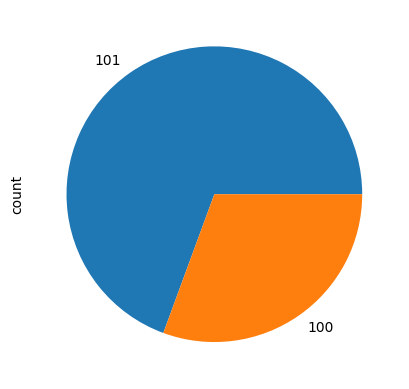

In [31]:
rockaways_df['arrest_precinct'].value_counts().plot(kind='pie')

In [32]:
#Create a Year-Month column for grouping
rockaways_df['year_month'] = rockaways_df['arrest_date'].dt.to_period('M')
#Group by month and count arrests
monthly_arrests = rockaways_df.groupby('year_month').size()

/tmp/ipykernel_23206/2323142460.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rockaways_df['year_month'] = rockaways_df['arrest_date'].dt.to_period('M')


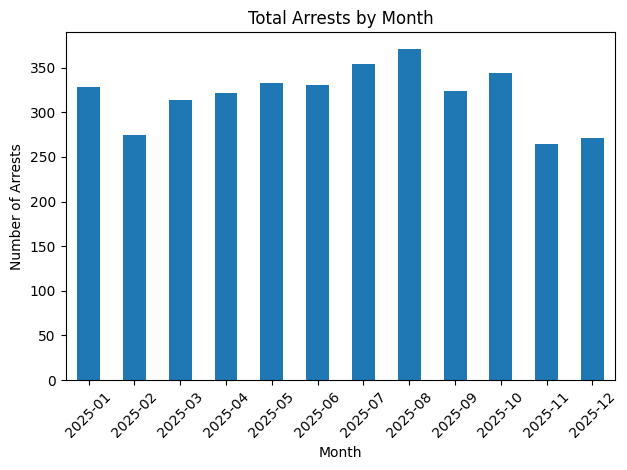

In [33]:
monthly_arrests.plot(kind='bar')

plt.title('Total Arrests by Month')
plt.xlabel('Month')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

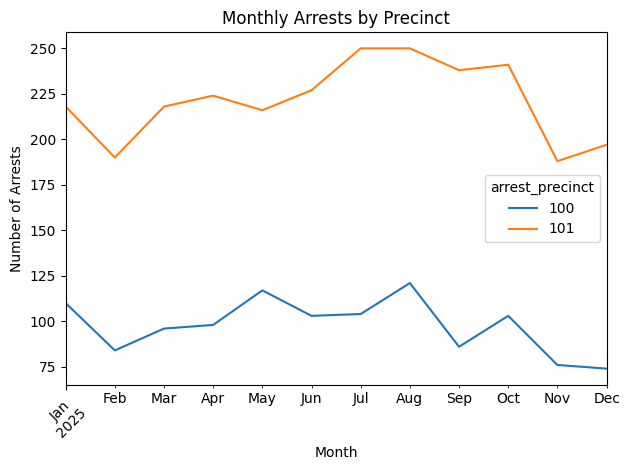

In [34]:
monthly_precinct = rockaways_df.groupby(['year_month', 'arrest_precinct']).size().unstack()
monthly_precinct.plot(kind='line')

plt.title('Monthly Arrests by Precinct')
plt.xlabel('Month')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [35]:
rockaways_df['ofns_desc'].value_counts()

,count
ofns_desc,
ASSAULT 3 & RELATED OFFENSES,657
MISCELLANEOUS PENAL LAW,499
FELONY ASSAULT,395
DANGEROUS DRUGS,226
DANGEROUS WEAPONS,223
PETIT LARCENY,207
CRIMINAL MISCHIEF & RELATED OF,206
VEHICLE AND TRAFFIC LAWS,194
SEX CRIMES,148


In [43]:
top10_100 = rockaways_df[rockaways_df['arrest_precinct'] == 100].groupby('ofns_desc').size().sort_values(ascending=False).head(10)
print(top10_100)

ofns_desc
ASSAULT 3 & RELATED OFFENSES      221
MISCELLANEOUS PENAL LAW           175
PETIT LARCENY                     109
FELONY ASSAULT                     96
CRIMINAL MISCHIEF & RELATED OF     93
SEX CRIMES                         50
VEHICLE AND TRAFFIC LAWS           50
DANGEROUS DRUGS                    49
OFF. AGNST PUB ORD SENSBLTY &      42
ROBBERY                            40
dtype: int64


In [44]:
top10_101 = rockaways_df[rockaways_df['arrest_precinct'] == 101].groupby('ofns_desc').size().sort_values(ascending=False).head(10)
print(top10_101)

ofns_desc
ASSAULT 3 & RELATED OFFENSES      436
MISCELLANEOUS PENAL LAW           324
FELONY ASSAULT                    299
DANGEROUS WEAPONS                 189
DANGEROUS DRUGS                   177
VEHICLE AND TRAFFIC LAWS          144
CRIMINAL MISCHIEF & RELATED OF    113
OFFENSES AGAINST PUBLIC ADMINI    112
PETIT LARCENY                      98
SEX CRIMES                         98
dtype: int64


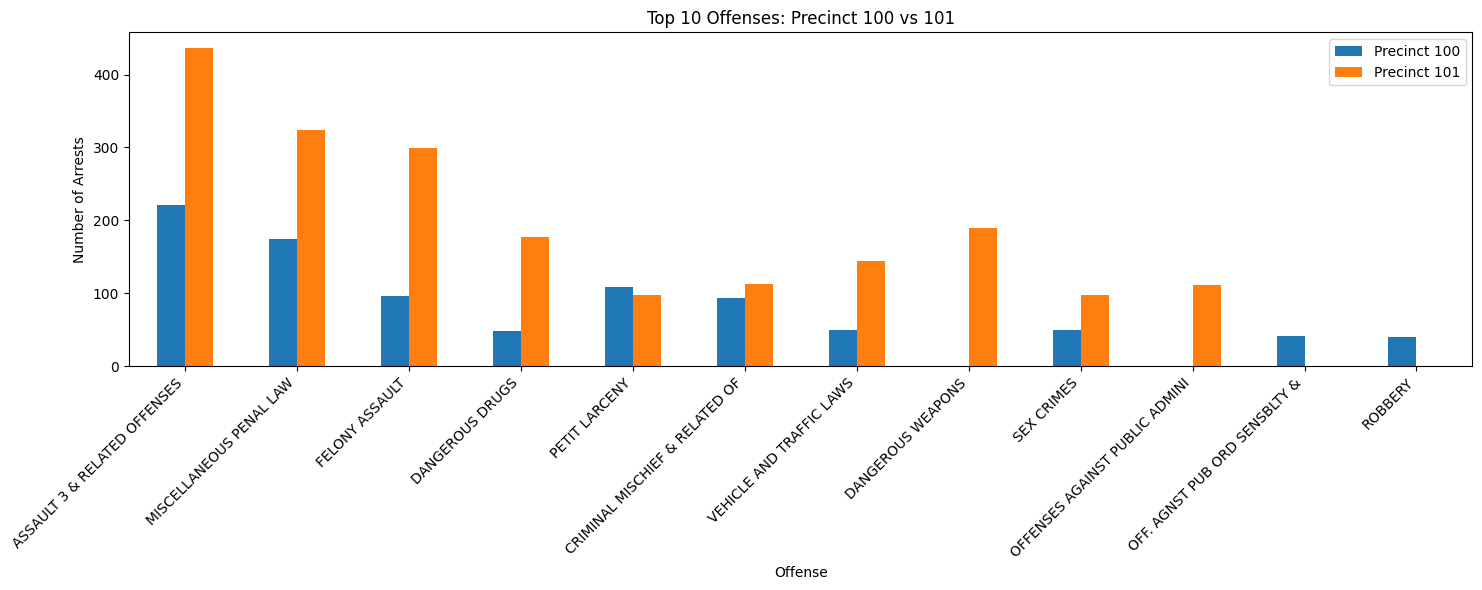

In [45]:
# Creating a combination plot to show comparison for number of arrests by precinct and offense
#issue: we have two different top 10 lists, which likely don’t have the same offenses and therefore, don't align for plotting
#align both before plotting

# Create combined offense list
combined_index = top10_100.index.union(top10_101.index)

# Align both Series (fill missing with 0)
top10_100_aligned = top10_100.reindex(combined_index, fill_value=0)
top10_101_aligned = top10_101.reindex(combined_index, fill_value=0)

# Combine into one DataFrame
comparison = pd.DataFrame({
    'Precinct 100': top10_100_aligned,
    'Precinct 101': top10_101_aligned
})

# Sort by total arrests
comparison['Total'] = comparison.sum(axis=1)
comparison = comparison.sort_values(by='Total', ascending=False)

# Plot
comparison[['Precinct 100', 'Precinct 101']].plot(kind='bar', figsize=(15, 6))

plt.title('Top 10 Offenses: Precinct 100 vs 101')
plt.xlabel('Offense')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()
